## Spearman (ранговая корреляция) — отдельная задача ранжирования

Этот блок **не использует бинаризацию**. Он строит таблицу коэффициентов Спирмена \(\rho_S\) по исходным числовым признакам как корреляцию их **рангов**.

In [1]:
import os
import numpy as np
import pandas as pd

os.makedirs("tables", exist_ok=True)

# Автономная загрузка
_df = pd.read_csv("diabetes.csv")
_feat = [c for c in _df.columns if c != "Outcome"]
X = _df[_feat].astype(float)

# 1) Матрица rho_S (Spearman) через ранги
spearman_rho = X.corr(method="spearman")

# 2) (Опционально) p-values, если доступен SciPy
spearman_p = None
try:
    from scipy.stats import spearmanr  # type: ignore

    rho, p = spearmanr(X.to_numpy(), axis=0)
    spearman_rho = pd.DataFrame(rho, index=_feat, columns=_feat)
    spearman_p = pd.DataFrame(p, index=_feat, columns=_feat)
except Exception as e:
    print("SciPy недоступен или spearmanr не сработал; p-values не рассчитаны.")
    print("Причина:", repr(e))

print("Spearman rho matrix (head):")
display(spearman_rho.head())

# Сохранение (CSV + LaTeX)
rho_csv = os.path.join("tables", "spearman_rho_matrix.csv")
spearman_rho.to_csv(rho_csv, encoding="utf-8-sig")

rho_tex = os.path.join("tables", "spearman_rho_matrix.tex")
spearman_rho.round(4).to_latex(rho_tex)

print("Saved:", rho_csv)
print("Saved:", rho_tex)

if spearman_p is not None:
    p_csv = os.path.join("tables", "spearman_p_matrix.csv")
    spearman_p.to_csv(p_csv, encoding="utf-8-sig")

    p_tex = os.path.join("tables", "spearman_p_matrix.tex")
    spearman_p.round(6).to_latex(p_tex)

    print("Saved:", p_csv)
    print("Saved:", p_tex)

# Быстрый рейтинг самых сильных связей по |rho|
abs_rho = spearman_rho.abs().copy()
np.fill_diagonal(abs_rho.values, np.nan)
rank = (
    abs_rho.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "i", "level_1": "j", 0: "abs_rho"})
)

# Убираем дубли пар (i,j) и (j,i)
rank["pair"] = rank.apply(lambda r: "::".join(sorted([r["i"], r["j"]])), axis=1)
rank = rank.drop_duplicates("pair").drop(columns=["pair"])

rank_path = os.path.join("tables", "spearman_abs_rho_ranking.csv")
rank.to_csv(rank_path, index=False, encoding="utf-8-sig")

print("Top-10 |rho| pairs:")
display(rank.head(10))
print("Saved:", rank_path)

Spearman rho matrix (head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.130734,0.185127,-0.085222,-0.126723,0.000132,-0.043242,0.607216
Glucose,0.130734,1.000000,0.235191,0.060022,0.213206,0.231141,0.091293,0.285045
BloodPressure,0.185127,0.235191,1.000000,0.126486,-0.006771,0.292870,0.030046,0.350895
SkinThickness,-0.085222,0.060022,0.126486,1.000000,0.541000,0.443615,0.180390,-0.066795
Insulin,-0.126723,0.213206,-0.006771,0.541000,1.000000,0.192726,0.221150,-0.114213


Saved: tables\spearman_rho_matrix.csv
Saved: tables\spearman_rho_matrix.tex
Saved: tables\spearman_p_matrix.csv
Saved: tables\spearman_p_matrix.tex
Top-10 |rho| pairs:


,i,j,abs_rho
0,Pregnancies,Age,0.607216
2,Insulin,SkinThickness,0.541000
4,SkinThickness,BMI,0.443615
6,Age,BloodPressure,0.350895
8,BloodPressure,BMI,0.292870
10,Age,Glucose,0.285045
12,BloodPressure,Glucose,0.235191
14,Glucose,BMI,0.231141
16,DiabetesPedigreeFunction,Insulin,0.221150
18,Glucose,Insulin,0.213206


Saved: tables\spearman_abs_rho_ranking.csv


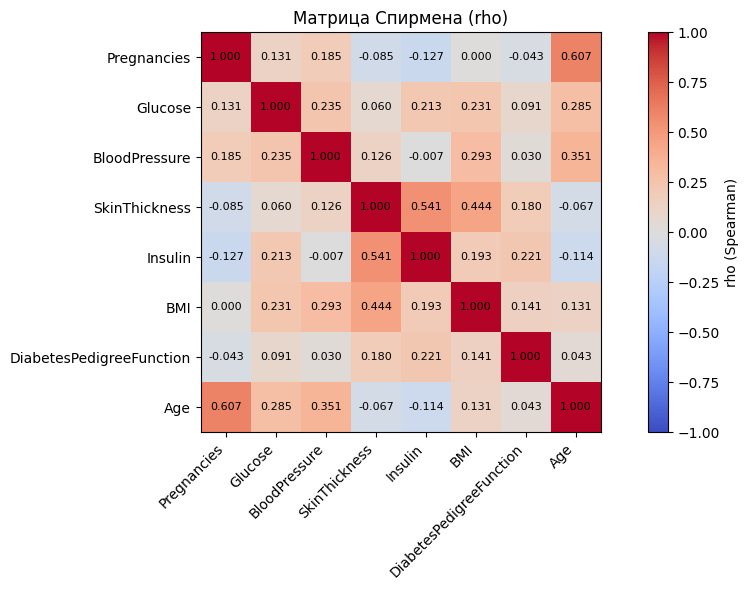

Saved: images\spearman_rho_heatmap.png


In [2]:
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

# Тепловая карта (как для r_B), но для Spearman rho
M = spearman_rho.copy()
labels = list(M.columns)
vals = M.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(vals, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Подписи значений
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.3f}", ha="center", va="center", fontsize=8, color="black")

ax.set_title("Матрица Спирмена (rho)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("rho (Spearman)")

fig.tight_layout()

out_png = os.path.join("images", "spearman_rho_heatmap.png")
fig.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

## Spearman с заданным числом ранговых уровней (K)

Если преподаватель требует «задать ранги вручную» (например, 5/10/100), это означает не классический Спирмен по исходным значениям, а **дискретизацию** каждого признака на K упорядоченных уровней (1..K), после чего считаем ранговую корреляцию уже по этим уровням.

Ниже реализован вариант через **квантили**: каждый столбец делится на K групп одинакового размера (примерно по 1/K выборки в каждой группе).

In [3]:
import numpy as np
import pandas as pd

# K — число уровней ("рангов"), которые вы хотите задать вручную
K_RANK_LEVELS = 10  # например 5, 10, 100


def quantile_levels(col: pd.Series, k: int) -> pd.Series:
    """Преобразует числовой столбец в уровни 1..k по квантилям (примерно равные группы)."""
    # qcut может "урезать" число бинов, если слишком много одинаковых значений
    levels = pd.qcut(col, q=k, labels=False, duplicates="drop")
    # levels в [0..k'-1], делаем [1..k']
    return (levels.astype(int) + 1).astype(int)


X_levels = pd.DataFrame({c: quantile_levels(X[c], K_RANK_LEVELS) for c in _feat})

# Реально получившееся число уровней может быть < K_RANK_LEVELS из-за ties
actual_levels = {c: int(X_levels[c].nunique()) for c in _feat}
print("Задано K =", K_RANK_LEVELS)
print("Фактически уровней по столбцам (из-за повторов может быть меньше):")
display(pd.Series(actual_levels).to_frame("n_levels"))

# Матрица "Spearman по уровням" (по сути связь между вашими заданными рангами)
spearman_rho_k = X_levels.corr(method="spearman")

print("Spearman rho по дискретным уровням (head):")
display(spearman_rho_k.head())

# Сохранение
out_rho_csv = f"tables/spearman_rho_levels_k{K_RANK_LEVELS}.csv"
out_rho_tex = f"tables/spearman_rho_levels_k{K_RANK_LEVELS}.tex"

spearman_rho_k.to_csv(out_rho_csv, encoding="utf-8-sig")
spearman_rho_k.round(4).to_latex(out_rho_tex)

print("Saved:", out_rho_csv)
print("Saved:", out_rho_tex)

# Рейтинг по |rho| для заданных уровней
abs_rho_k = spearman_rho_k.abs().copy()
np.fill_diagonal(abs_rho_k.values, np.nan)
rank_k = (
    abs_rho_k.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "i", "level_1": "j", 0: "abs_rho"})
)
rank_k["pair"] = rank_k.apply(lambda r: "::".join(sorted([r["i"], r["j"]])), axis=1)
rank_k = rank_k.drop_duplicates("pair").drop(columns=["pair"])

out_rank_csv = f"tables/spearman_abs_rho_levels_k{K_RANK_LEVELS}_ranking.csv"
rank_k.to_csv(out_rank_csv, index=False, encoding="utf-8-sig")

print("Top-10 |rho| pairs (уровни K):")
display(rank_k.head(10))
print("Saved:", out_rank_csv)

Задано K = 10
Фактически уровней по столбцам (из-за повторов может быть меньше):


,n_levels
Pregnancies,8
Glucose,10
BloodPressure,10
SkinThickness,8
Insulin,6
BMI,10
DiabetesPedigreeFunction,10
Age,10


Spearman rho по дискретным уровням (head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.143466,0.197345,-0.096825,-0.137003,0.014244,-0.042403,0.611701
Glucose,0.143466,1.000000,0.233818,0.068809,0.215205,0.233735,0.083916,0.285458
BloodPressure,0.197345,0.233818,1.000000,0.114223,-0.015407,0.282666,0.023442,0.349980
SkinThickness,-0.096825,0.068809,0.114223,1.000000,0.531021,0.437342,0.171838,-0.066855
Insulin,-0.137003,0.215205,-0.015407,0.531021,1.000000,0.190589,0.217507,-0.101524


Saved: tables/spearman_rho_levels_k10.csv
Saved: tables/spearman_rho_levels_k10.tex
Top-10 |rho| pairs (уровни K):


,i,j,abs_rho
0,Pregnancies,Age,0.611701
2,SkinThickness,Insulin,0.531021
4,SkinThickness,BMI,0.437342
6,Age,BloodPressure,0.349980
8,Glucose,Age,0.285458
10,BMI,BloodPressure,0.282666
12,Glucose,BloodPressure,0.233818
14,Glucose,BMI,0.233735
16,DiabetesPedigreeFunction,Insulin,0.217507
18,Insulin,Glucose,0.215205


Saved: tables/spearman_abs_rho_levels_k10_ranking.csv


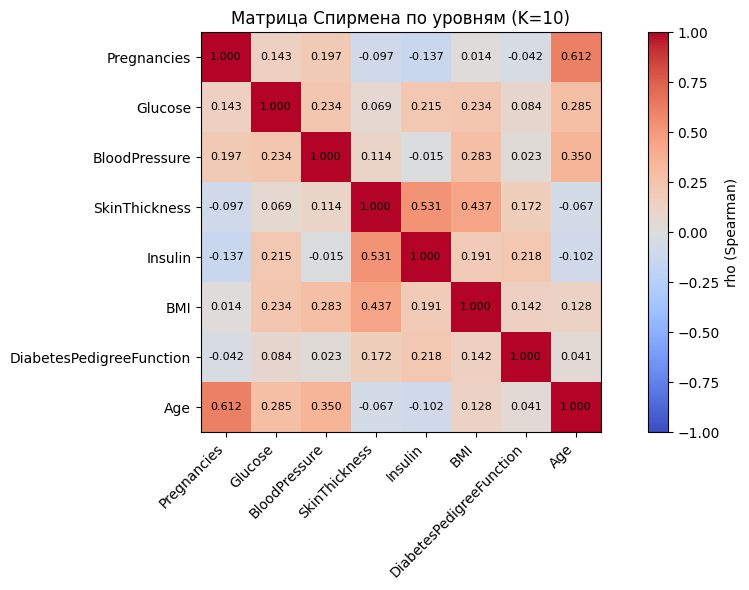

Saved: images\spearman_rho_levels_k10_heatmap.png


In [4]:
import matplotlib.pyplot as plt

# Heatmap для Spearman по дискретным уровням (K)
M_k = spearman_rho_k.copy()
labels_k = list(M_k.columns)
vals_k = M_k.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(vals_k, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(labels_k)))
ax.set_yticks(np.arange(len(labels_k)))
ax.set_xticklabels(labels_k, rotation=45, ha="right")
ax.set_yticklabels(labels_k)

for i in range(vals_k.shape[0]):
    for j in range(vals_k.shape[1]):
        ax.text(j, i, f"{vals_k[i, j]:.3f}", ha="center", va="center", fontsize=8, color="black")

ax.set_title(f"Матрица Спирмена по уровням (K={K_RANK_LEVELS})")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("rho (Spearman)")

fig.tight_layout()

out_png_k = os.path.join("images", f"spearman_rho_levels_k{K_RANK_LEVELS}_heatmap.png")
fig.savefig(out_png_k, dpi=200)
plt.show()

print("Saved:", out_png_k)

## Подбор числа уровней ранга K (перебор 3…10)

Здесь **K — это число уровней (квантильных групп)**, на которые мы *по каждому признаку отдельно* дискретизируем значения (через `qcut`).

Это **не означает**, что «объекты делятся на K кластеров» — это именно *K бинов на оси каждого признака*.

Идейно перебор допустим, но нужно выбрать критерий. Ниже используем два:

- близость матрицы \(\rho_S\) после дискретизации к базовой \(\rho_S\) по непрерывным рангам;
- качество восстановления (\(R^2\)) удалённых признаков из выбранных 4 (на рангах).


Selected4 used in K-sweep: ['DiabetesPedigreeFunction', 'BloodPressure', 'SkinThickness', 'Pregnancies']
Removed4 used in K-sweep: ['Glucose', 'Insulin', 'BMI', 'Age']


,K,frob_err_to_base,mean_r2_reconstruct_removed4,min_r2_reconstruct_removed4
0,3,0.351958,0.221784,0.068806
1,4,0.296758,0.250515,0.089533
2,5,0.255745,0.248172,0.080706
3,6,0.106894,0.258975,0.069078
4,7,0.248016,0.258076,0.069062
5,8,0.147288,0.263861,0.079770
6,9,0.156205,0.261937,0.073062
7,10,0.058211,0.266941,0.073209


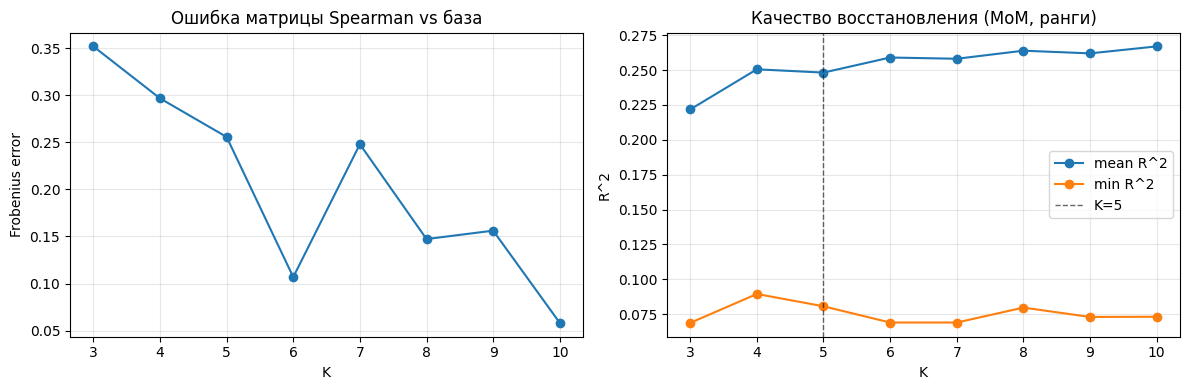

Saved: images\k_sweep_metrics_3_10.png
Recommended K (rule-based): 10
Row for K=5:


,K,frob_err_to_base,mean_r2_reconstruct_removed4,min_r2_reconstruct_removed4
2,5,0.255745,0.248172,0.080706


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("tables", exist_ok=True)
os.makedirs("images", exist_ok=True)

# База: Spearman по непрерывным рангам
R0 = X.rank(method="average")
rho_base = R0.corr(method="pearson")


def levels_qcut_frame(Xdf: pd.DataFrame, k: int) -> pd.DataFrame:
    def qlevels(col: pd.Series) -> pd.Series:
        lv = pd.qcut(col, q=k, labels=False, duplicates="drop")
        return (lv.astype(int) + 1).astype(int)

    return pd.DataFrame({c: qlevels(Xdf[c]) for c in Xdf.columns})


def frob(A: pd.DataFrame, B: pd.DataFrame) -> float:
    D = (A.to_numpy(float) - B.to_numpy(float))
    return float(np.sqrt((D * D).sum()))


# Для критерия понижения размерности используем 4 признака, выбранные по Spearman-базе.
# Важно: этот блок должен работать автономно (без зависимости от ячеек ниже).
_feats_here = list(X.columns)
abs_rho0 = rho_base.abs()


def _greedy_select_k(features_list, abs_rho_mat: pd.DataFrame, k: int = 4):
    feats = list(features_list)
    mean_abs = abs_rho_mat.loc[feats, feats].mean(axis=1)
    sel = [mean_abs.idxmin()]
    while len(sel) < k:
        remaining = [f for f in feats if f not in sel]
        scores = {f: abs_rho_mat.loc[f, sel].max() for f in remaining}
        sel.append(min(scores, key=scores.get))
    return sel


_selected4 = _greedy_select_k(_feats_here, abs_rho0, k=4)
_removed4 = [f for f in _feats_here if f not in _selected4]
print("Selected4 used in K-sweep:", _selected4)
print("Removed4 used in K-sweep:", _removed4)

def mom_lin_multi(Xm: np.ndarray, y: np.ndarray, ridge: float = 1e-10):
    Xm = np.asarray(Xm, float)
    y = np.asarray(y, float)
    mx = Xm.mean(axis=0)
    my = y.mean()
    Xc = Xm - mx
    yc = y - my
    Sigma = (Xc.T @ Xc) / len(y)
    Sigma = Sigma + ridge * np.eye(Sigma.shape[0])
    cov_xy = (Xc.T @ yc) / len(y)
    b = np.linalg.solve(Sigma, cov_xy)
    a = my - mx @ b
    y_hat = a + Xm @ b
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(a), b.astype(float), float(r2)


rows = []
for k in range(3, 11):
    Xk = levels_qcut_frame(X, k)

    # Spearman на дискретных уровнях
    rho_k = Xk.corr(method="spearman")

    # Метрики близости к base
    e_frob = frob(rho_k, rho_base)

    # Метрика по задаче 8→4: средний R^2 восстановления removed4 из selected4 (на рангах)
    Rk = Xk.rank(method="average")  # ранги по уровням (устойчиво)
    Xsel = Rk[_selected4].to_numpy()
    r2s = []
    for yname in _removed4:
        _, _, r2 = mom_lin_multi(Xsel, Rk[yname].to_numpy())
        r2s.append(r2)

    rows.append(
        {
            "K": k,
            "frob_err_to_base": e_frob,
            "mean_r2_reconstruct_removed4": float(np.nanmean(r2s)),
            "min_r2_reconstruct_removed4": float(np.nanmin(r2s)),
        }
    )

k_sweep = pd.DataFrame(rows).sort_values("K")
display(k_sweep)

k_sweep.to_csv(os.path.join("tables", "k_sweep_metrics_3_10.csv"), index=False, encoding="utf-8-sig")

# Визуализация: чем меньше ошибка — тем ближе к базовым рангам; чем больше R^2 — тем лучше восстановление
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_sweep["K"], k_sweep["frob_err_to_base"], marker="o")
ax[0].set_title("Ошибка матрицы Spearman vs база")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Frobenius error")
ax[0].grid(True, alpha=0.3)

ax[1].plot(k_sweep["K"], k_sweep["mean_r2_reconstruct_removed4"], marker="o", label="mean R^2")
ax[1].plot(k_sweep["K"], k_sweep["min_r2_reconstruct_removed4"], marker="o", label="min R^2")
ax[1].axvline(5, color="black", linestyle="--", linewidth=1, alpha=0.6, label="K=5")
ax[1].set_title("Качество восстановления (MoM, ранги)")
ax[1].set_xlabel("K")
ax[1].set_ylabel("R^2")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

fig.tight_layout()
out = os.path.join("images", "k_sweep_metrics_3_10.png")
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# Автовыбор по компромиссу: минимизируем ошибку, но требуем не деградировать сильно по mean R^2
# (простое правило: выбираем K с минимальной ошибкой среди K, где mean R^2 >= 0.95*максимума)
max_r2 = k_sweep["mean_r2_reconstruct_removed4"].max()
mask = k_sweep["mean_r2_reconstruct_removed4"] >= 0.95 * max_r2
cand = k_sweep[mask].sort_values(["frob_err_to_base", "K"]).head(1)
if len(cand) == 1:
    print("Recommended K (rule-based):", int(cand.iloc[0]["K"]))

print("Row for K=5:")
display(k_sweep[k_sweep["K"] == 5])


## Гипотеза о виде функции связи (монотонность) и выбор семейства

Раз мы опираемся на **Спирмена**, базовая гипотеза такая:

- связь между признаками **монотонная** (не обязательно линейная), т.е. при росте одного признака второй в среднем растёт/падает без смены направления.

Поэтому разумно тестировать **монотонные** семейства функций связи:

- линейная: \(y = a + b x\)
- экспоненциальная: \(y = a\,e^{b x}\) (\(y>0\))
- степенная: \(y = a x^{b}\) (\(x>0, y>0\))

Оценку параметров сделаем **методом моментов** через линеаризации (лог-преобразования) и выборочные моменты (средние/ковариации). Затем сравним качество (например, \(R^2\)).


In [6]:
import numpy as np
import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# MoM-оценки для линейной регрессии y = a + b x через моменты

def mom_lin_1d(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mx = x.mean()
    my = y.mean()
    vx = ((x - mx) ** 2).mean()
    if vx == 0:
        return float(my), 0.0
    cxy = ((x - mx) * (y - my)).mean()
    b = cxy / vx
    a = my - b * mx
    return float(a), float(b)


def r2_score(y: np.ndarray, yhat: np.ndarray) -> float:
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


# Сравнение семейств на ОРИГИНАЛЬНЫХ значениях X (не на рангах)
# Для устойчивости к нулям используем сдвиг eps только в тех моделях, где нужен log.
EPS = 1e-9


def fit_and_eval_models(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    out = []

    # 1) линейная y = a + b x
    a, b = mom_lin_1d(x, y)
    yhat = a + b * x
    out.append({"model": "linear", "a": a, "b": b, "r2": r2_score(y, yhat)})

    # 2) экспонента y = a * exp(b x)  => ln(y) = ln(a) + b x
    # Требует y>0
    mask = y > 0
    if mask.sum() >= 3:
        yy = np.log(y[mask])
        xx = x[mask]
        la, b2 = mom_lin_1d(xx, yy)  # la = ln(a)
        a2 = float(np.exp(la))
        yhat2 = a2 * np.exp(b2 * x)
        out.append({"model": "exp", "a": a2, "b": float(b2), "r2": r2_score(y, yhat2)})

    # 3) степенная y = a * x^b  => ln(y) = ln(a) + b ln(x)
    # Требует x>0, y>0
    mask = (x > 0) & (y > 0)
    if mask.sum() >= 3:
        xx = np.log(x[mask])
        yy = np.log(y[mask])
        la, b3 = mom_lin_1d(xx, yy)
        a3 = float(np.exp(la))
        yhat3 = a3 * np.power(np.maximum(x, EPS), b3)
        out.append({"model": "power", "a": a3, "b": float(b3), "r2": r2_score(y, yhat3)})

    return out


# Для выбора x и набора "удалённых" признаков сделаем этот блок автономным:
# 1) считаем Spearman по рангам
# 2) выбираем selected4 жадно (минимум избыточности)
R_rank = X.rank(method="average")
rho_rank = R_rank.corr(method="pearson")
abs_rho = rho_rank.abs()

feats_here = list(X.columns)

def greedy_select_k(features_list, abs_rho_mat: pd.DataFrame, k: int = 4):
    feats = list(features_list)
    mean_abs = abs_rho_mat.loc[feats, feats].mean(axis=1)
    sel = [mean_abs.idxmin()]
    while len(sel) < k:
        remaining = [f for f in feats if f not in sel]
        scores = {f: abs_rho_mat.loc[f, sel].max() for f in remaining}
        sel.append(min(scores, key=scores.get))
    return sel

selected4_local = greedy_select_k(feats_here, abs_rho, k=4)
removed4_local = [f for f in feats_here if f not in selected4_local]

print("selected4 (for model choice):", selected4_local)
print("removed4 (for model choice):", removed4_local)

# Для каждой "удалённой" переменной y сравним модели по отношению к наиболее связанному x среди selected4
results = []
for yname in removed4_local:
    best_x = abs_rho.loc[yname, selected4_local].idxmax()

    x = X[best_x].to_numpy()
    y = X[yname].to_numpy()

    fits = fit_and_eval_models(x, y)
    for fit in fits:
        results.append({"y": yname, "x": best_x, **fit})

model_cmp = pd.DataFrame(results)
# лучшая модель по R^2 для каждого y
best = model_cmp.sort_values(["y", "r2"], ascending=[True, False]).groupby("y", as_index=False).head(1)

print("Model choice (by R^2) for each removed feature y using best x among selected4:")
display(best)

best.to_csv(os.path.join("tables", "link_function_model_choice_mom.csv"), index=False, encoding="utf-8-sig")


selected4 (for model choice): ['DiabetesPedigreeFunction', 'BloodPressure', 'SkinThickness', 'Pregnancies']
removed4 (for model choice): ['Glucose', 'Insulin', 'BMI', 'Age']
Model choice (by R^2) for each removed feature y using best x among selected4:


,y,x,model,a,b,r2
9,Age,Pregnancies,linear,25.935993,1.899816,0.296307
7,BMI,SkinThickness,exp,28.481664,0.005211,0.155862
0,Glucose,BloodPressure,linear,103.476293,0.252053,0.023284
5,Insulin,SkinThickness,power,37.492106,0.359031,0.207824


## Функции связи и понижение размерности (8 → 4) на основе Спирмена

Ниже:

- строим **ранговые** (на рангах) функции связи, согласованные с коэффициентом Спирмена;
- выбираем 4 признака с минимальной взаимной избыточностью по \(|\rho_S|\);
- для остальных 4 признаков строим модель восстановления по выбранным 4 и оцениваем параметры **методом моментов** (по 1–2 моментам: средние/ковариации), т.е. через формулы на основе выборочных моментов.


In [7]:
import numpy as np
import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# Данные (8 признаков без Outcome)
df = pd.read_csv("diabetes.csv")
features = [c for c in df.columns if c != "Outcome"]
X = df[features].astype(float)

# Ранги (для согласования с Spearman)
R = X.rank(method="average")

# Матрица Спирмена уже могла быть рассчитана выше; на всякий случай пересчитаем от рангов
spearman_rho_rank = R.corr(method="pearson")

# --- 1) Выбор 4 "сильных" признаков по Spearman ---
# Гипотеза: "сильный" признак — тот, у которого в среднем высокая монотонная связь
# с остальными признаками, т.е. большой mean(|rho_S|) по строке матрицы.
abs_rho = spearman_rho_rank.abs().copy()
np.fill_diagonal(abs_rho.values, np.nan)

strength = abs_rho.mean(axis=1).sort_values(ascending=False)
selected4 = strength.head(4).index.tolist()
removed4 = [f for f in features if f not in selected4]

print("Selected 4 strong features (top mean |rho_S|):", selected4)
print("Removed 4 features:", removed4)

pd.DataFrame({"selected4": selected4, "strength_mean_abs_rho": strength.loc[selected4].values}).to_csv(
    os.path.join("tables", "selected4_strong_features.csv"), index=False, encoding="utf-8-sig"
)

# --- 2) Функции связи по парной ранговой зависимости (y_rank = a + b * x_rank) ---
# Метод моментов для линейной зависимости на рангах:
# b = Cov(rX, rY) / Var(rX), a = E[rY] - b*E[rX]
# (Cov/Var — это выборочные моменты 2-го порядка)

def mom_lin_1d(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mx = x.mean()
    my = y.mean()
    vx = ((x - mx) ** 2).mean()
    if vx == 0:
        return float(my), 0.0
    cxy = ((x - mx) * (y - my)).mean()
    b = cxy / vx
    a = my - b * mx
    return float(a), float(b)

pair_models = []
for y in features:
    # для каждого y берём x с максимальным |rho| (кроме самого себя)
    candidates = [c for c in features if c != y]
    best_x = abs_rho.loc[y, candidates].idxmax()
    a, b = mom_lin_1d(R[best_x].to_numpy(), R[y].to_numpy())
    pair_models.append(
        {
            "y": y,
            "x_best": best_x,
            "abs_rho": float(abs_rho.loc[y, best_x]),
            "a_rank": a,
            "b_rank": b,
        }
    )

pair_models_df = pd.DataFrame(pair_models).sort_values("abs_rho", ascending=False)
print("\nTop pairwise rank-link models (by |rho_S|):")
display(pair_models_df.head(10))

pair_models_df.to_csv(
    os.path.join("tables", "rank_pair_link_models.csv"), index=False, encoding="utf-8-sig"
)

# --- 3) Понижение размерности: восстановление удалённых 4 по выбранным 4 ---
# Модель на рангах: rY = a + rX_selected @ b
# Метод моментов (многомерный): b = Sigma^{-1} * cov(X, Y)
# где Sigma = Cov(X_selected), cov(X,Y) — вектор ковариаций.

def mom_lin_multi(Xm: np.ndarray, y: np.ndarray, ridge: float = 1e-10):
    Xm = np.asarray(Xm, float)
    y = np.asarray(y, float)
    mx = Xm.mean(axis=0)
    my = y.mean()

    Xc = Xm - mx
    yc = y - my

    Sigma = (Xc.T @ Xc) / len(y)
    # стабилизация на случай почти линейной зависимости
    Sigma = Sigma + ridge * np.eye(Sigma.shape[0])
    cov_xy = (Xc.T @ yc) / len(y)

    b = np.linalg.solve(Sigma, cov_xy)
    a = my - mx @ b

    y_hat = a + Xm @ b
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return float(a), b.astype(float), float(r2)

Xsel = R[selected4].to_numpy()
recon_rows = []
for y in removed4:
    a, b, r2 = mom_lin_multi(Xsel, R[y].to_numpy())
    row = {"y": y, "a_rank": a, "r2": r2}
    for name, coef in zip(selected4, b):
        row[f"b_rank[{name}]"] = float(coef)
    recon_rows.append(row)

recon_df = pd.DataFrame(recon_rows).sort_values("r2", ascending=False)
print("\nReconstruction of removed features from selected4 (rank-linear, MoM):")
display(recon_df)

recon_df.to_csv(
    os.path.join("tables", "rank_reconstruction_from_selected4_mom.csv"),
    index=False,
    encoding="utf-8-sig",
)

# Читабельные формулы
formulas = []
for _, row in recon_df.iterrows():
    y = row["y"]
    a = row["a_rank"]
    terms = [f"({row[f'b_rank[{x}]']:.6f})·r({x})" for x in selected4]
    formulas.append({"y": y, "formula": f"r({y}) = {a:.6f} + " + " + ".join(terms), "r2": row["r2"]})

# --- 4) Вывод функций связи ---

# 4.1) Парные функции (для каждого y берём x с макс |rho|): r(y) = a + b*r(x_best)
print("\nPairwise rank-link functions r(y) = a + b*r(x_best):")
for _, row in pair_models_df.sort_values("y").iterrows():
    y = row["y"]
    x = row["x_best"]
    a = float(row["a_rank"])
    b = float(row["b_rank"])
    rho = float(row["abs_rho"])
    print(f"  r({y}) = {a:.6f} + ({b:.6f}) * r({x})   (|rho_S|={rho:.6f})")

# 4.2) Итоговые функции восстановления удалённых 4 через выбранные 4:
# r(y) = a + sum_j b_j * r(x_j)
print("\nReconstruction functions from selected4 (rank-linear, MoM):")
recon_formulas = []
for _, row in recon_df.iterrows():
    y = row["y"]
    a = float(row["a_rank"])
    parts = [f"({float(row[f'b_rank[{x}]']):.6f}) * r({x})" for x in selected4]
    fml = f"r({y}) = {a:.6f} + " + " + ".join(parts)
    r2 = float(row["r2"])
    print(f"  {fml}   (R^2={r2:.6f})")
    recon_formulas.append({"y": y, "formula": fml, "r2": r2})

formulas_df = pd.DataFrame(recon_formulas)
display(formulas_df)
formulas_df.to_csv(
    os.path.join("tables", "rank_reconstruction_formulas.csv"),
    index=False,
    encoding="utf-8-sig",
)


Selected 4 strong features (top mean |rho_S|): ['Age', 'SkinThickness', 'BMI', 'Insulin']
Removed 4 features: ['Pregnancies', 'Glucose', 'BloodPressure', 'DiabetesPedigreeFunction']

Top pairwise rank-link models (by |rho_S|):


,y,x_best,abs_rho,a_rank,b_rank
0,Pregnancies,Age,0.607216,152.332836,0.603816
7,Age,Pregnancies,0.607216,149.710435,0.610636
4,Insulin,SkinThickness,0.541000,186.253944,0.515594
3,SkinThickness,Insulin,0.541000,166.235612,0.567658
5,BMI,SkinThickness,0.443615,211.656660,0.449528
2,BloodPressure,Age,0.350895,249.572623,0.350916
1,Glucose,Age,0.285045,274.774379,0.285372
6,DiabetesPedigreeFunction,Insulin,0.221150,294.086333,0.235146



Reconstruction of removed features from selected4 (rank-linear, MoM):


,y,a_rank,r2,b_rank[Age],b_rank[SkinThickness],b_rank[BMI],b_rank[Insulin]
0,Pregnancies,193.962136,0.377090,0.609425,0.018560,-0.077975,-0.054463
2,BloodPressure,166.929054,0.188976,0.319855,0.078085,0.227189,-0.059275
1,Glucose,141.089859,0.182872,0.279291,-0.182487,0.216459,0.319793
3,DiabetesPedigreeFunction,237.693451,0.063322,0.057661,0.050701,0.075578,0.197872



Pairwise rank-link functions r(y) = a + b*r(x_best):
  r(Age) = 149.710435 + (0.610636) * r(Pregnancies)   (|rho_S|=0.607216)
  r(BMI) = 211.656660 + (0.449528) * r(SkinThickness)   (|rho_S|=0.443615)
  r(BloodPressure) = 249.572623 + (0.350916) * r(Age)   (|rho_S|=0.350895)
  r(DiabetesPedigreeFunction) = 294.086333 + (0.235146) * r(Insulin)   (|rho_S|=0.221150)
  r(Glucose) = 274.774379 + (0.285372) * r(Age)   (|rho_S|=0.285045)
  r(Insulin) = 186.253944 + (0.515594) * r(SkinThickness)   (|rho_S|=0.541000)
  r(Pregnancies) = 152.332836 + (0.603816) * r(Age)   (|rho_S|=0.607216)
  r(SkinThickness) = 166.235612 + (0.567658) * r(Insulin)   (|rho_S|=0.541000)

Reconstruction functions from selected4 (rank-linear, MoM):
  r(Pregnancies) = 193.962136 + (0.609425) * r(Age) + (0.018560) * r(SkinThickness) + (-0.077975) * r(BMI) + (-0.054463) * r(Insulin)   (R^2=0.377090)
  r(BloodPressure) = 166.929054 + (0.319855) * r(Age) + (0.078085) * r(SkinThickness) + (0.227189) * r(BMI) + (-0.059275)

,y,formula,r2
0,Pregnancies,r(Pregnancies) = 193.962136 + (0.609425) * r(A...,0.377090
1,BloodPressure,r(BloodPressure) = 166.929054 + (0.319855) * r...,0.188976
2,Glucose,r(Glucose) = 141.089859 + (0.279291) * r(Age) ...,0.182872
3,DiabetesPedigreeFunction,r(DiabetesPedigreeFunction) = 237.693451 + (0....,0.063322


## Проверка степенной зависимости \(\xi_1 = \alpha\,\xi_2^{\beta}\) для выбранных пар

Ниже проверяем гипотезу степенной зависимости на исходных значениях признаков.

Оценка параметров **методом моментов** делается через линеаризацию:

\[\ln(\xi_1) = \ln(\alpha) + \beta\,\ln(\xi_2).\]

То есть:

- \(\beta = \mathrm{Cov}(\ln \xi_2, \ln \xi_1) / \mathrm{Var}(\ln \xi_2)\)
- \(\ln(\alpha) = \mathbb{E}[\ln \xi_1] - \beta\,\mathbb{E}[\ln \xi_2]\)

Проверка “подтвердилась/нет” делается по метрике \(R^2\) (порог задаётся в коде).


In [8]:
import numpy as np
import pandas as pd
import os

os.makedirs("tables", exist_ok=True)

# Какие пары проверяем:
# - по умолчанию берём пары внутри текущего selected4 (сильные признаки), все комбинации.
# Если хотите только топ-N пар по |rho_S| — скажите, заменю.

KS_ALPHA = 0.05  # уровень значимости для критерия Колмогорова–Смирнова


def mom_lin_1d(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mx = x.mean()
    my = y.mean()
    vx = ((x - mx) ** 2).mean()
    if vx == 0:
        return float(my), 0.0
    cxy = ((x - mx) * (y - my)).mean()
    b = cxy / vx
    a = my - b * mx
    return float(a), float(b)


def ks_2sample_pvalue(x: np.ndarray, y: np.ndarray):
    """2-sample KS test p-value for samples x and y. Uses SciPy if available, else normal approx."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n = len(x)
    m = len(y)
    if n < 3 or m < 3:
        return np.nan, np.nan

    try:
        from scipy.stats import ks_2samp  # type: ignore

        res = ks_2samp(x, y, alternative="two-sided", mode="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        # Fallback: approximate p-value for 2-sample KS
        x_sorted = np.sort(x)
        y_sorted = np.sort(y)
        data_all = np.sort(np.concatenate([x_sorted, y_sorted]))
        cdf_x = np.searchsorted(x_sorted, data_all, side="right") / n
        cdf_y = np.searchsorted(y_sorted, data_all, side="right") / m
        d = float(np.max(np.abs(cdf_x - cdf_y)))

        en = np.sqrt(n * m / (n + m))
        lam = (en + 0.12 + 0.11 / en) * d
        # Q_KS(lam) ≈ 2 Σ (-1)^{j-1} exp(-2 j^2 lam^2)
        j = np.arange(1, 200)
        p = 2.0 * np.sum(((-1) ** (j - 1)) * np.exp(-2.0 * (j * j) * (lam * lam)))
        p = float(np.clip(p, 0.0, 1.0))
        return d, p


def fit_power_mom_and_ks(x2: np.ndarray, x1: np.ndarray):
    """Fit x1 = alpha * x2^beta using MoM on logs. Returns (alpha,beta,ks_stat,ks_p,n_used)."""
    x2 = np.asarray(x2, float)
    x1 = np.asarray(x1, float)

    mask = (x2 > 0) & (x1 > 0) & np.isfinite(x2) & np.isfinite(x1)
    n = int(mask.sum())
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan, n

    z2 = np.log(x2[mask])
    z1 = np.log(x1[mask])

    ln_a, beta = mom_lin_1d(z2, z1)
    alpha = float(np.exp(ln_a))

    x1_hat = alpha * np.power(x2[mask], beta)
    ks_stat, ks_p = ks_2sample_pvalue(x1[mask], x1_hat)

    return float(alpha), float(beta), float(ks_stat), float(ks_p), n


# определяем selected4, если вдруг ячейки выше не выполнялись
try:
    feats_sel = list(selected4)
except NameError:
    feats_sel = ["Age", "SkinThickness", "BMI", "Insulin"]

pairs = []
for i in range(len(feats_sel)):
    for j in range(i + 1, len(feats_sel)):
        a = feats_sel[i]
        b = feats_sel[j]
        pairs.append((a, b))

rows = []
for (f1, f2) in pairs:
    # проверяем обе ориентации: xi1=alpha*xi2^beta
    alpha_12, beta_12, ks_12, p_12, n12 = fit_power_mom_and_ks(X[f2].to_numpy(), X[f1].to_numpy())
    alpha_21, beta_21, ks_21, p_21, n21 = fit_power_mom_and_ks(X[f1].to_numpy(), X[f2].to_numpy())

    # выбираем ориентацию с лучшим p-value (менее противоречит гипотезе)
    p12 = np.nan_to_num(p_12, nan=-np.inf)
    p21 = np.nan_to_num(p_21, nan=-np.inf)

    if p12 >= p21:
        xi1, xi2 = f1, f2
        alpha, beta, ks_stat, ks_p, n_used = alpha_12, beta_12, ks_12, p_12, n12
    else:
        xi1, xi2 = f2, f1
        alpha, beta, ks_stat, ks_p, n_used = alpha_21, beta_21, ks_21, p_21, n21

    confirmed = bool(np.isfinite(ks_p) and (ks_p >= KS_ALPHA))

    rows.append(
        {
            "xi1": xi1,
            "xi2": xi2,
            "alpha": alpha,
            "beta": beta,
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "n_used": n_used,
            "confirmed": "подтвердилась" if confirmed else "не подтвердилась",
        }
    )

power_check = pd.DataFrame(rows).sort_values(["confirmed", "ks_p"], ascending=[False, False])
display(power_check)

out_csv = os.path.join("tables", "power_law_check_selected_pairs.csv")
power_check.to_csv(out_csv, index=False, encoding="utf-8-sig")
print("Saved:", out_csv)


,xi1,xi2,alpha,beta,ks_stat,ks_p,n_used,confirmed
3,BMI,SkinThickness,9.872570,0.357842,0.131725,1.703173e-04,539,не подтвердилась
5,BMI,Insulin,21.544222,0.084516,0.284987,1.833708e-14,393,не подтвердилась
2,Insulin,Age,14.877185,0.623370,0.365482,8.655518e-24,394,не подтвердилась
4,Insulin,SkinThickness,37.492106,0.359031,0.375635,3.867248e-25,394,не подтвердилась
0,SkinThickness,Age,11.764188,0.246236,0.377079,1.219139e-34,541,не подтвердилась
1,BMI,Age,26.773631,0.049293,0.446499,2.718400e-68,757,не подтвердилась


Saved: tables\power_law_check_selected_pairs.csv
